In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# output directory for plots
os.makedirs('../plots', exist_ok=True)
output_dir = '../plots/'

# Read results
df = pd.read_csv('../data/runs.csv')

df

,Threads,Result,Time
0,1,1365.33,0.651132
1,1,1365.33,0.652293
2,1,1365.33,0.650855
3,1,1365.33,0.649748
4,1,1365.33,0.650012
...,...,...,...
115,12,1365.33,0.054134
116,12,1365.33,0.054132
117,12,1365.33,0.054121
118,12,1365.33,0.054121


In [16]:
# Normalize column names (remove accidental leading/trailing spaces)
df.columns = df.columns.str.strip()

# Compute average time per thread count
avg_df = df.groupby('Threads', as_index=False)['Time'].mean().rename(columns={'Time': 'seconds'})

# Show the resulting dataframe
avg_df

,Threads,seconds
0,1,0.650162
1,2,0.325174
2,3,0.217001
3,4,0.165862
4,5,0.133962
5,6,0.118568
6,7,0.096831
7,8,0.083804
8,9,0.073660
9,10,0.074565


In [15]:
# Speedup
T1 = avg_df['seconds'].iloc[0]
avg_df['Speedup'] = T1 / avg_df['seconds']

# Efficiency
avg_df['Efficiency'] = avg_df['Speedup'] / avg_df['Threads']
# Karp-Flatt
avg_df['Karp_Flatt'] = ((1 / avg_df['Speedup']) - (1 / avg_df['Threads'])) / (1 - (1 / avg_df['Threads']))

avg_df

,Threads,seconds,Speedup,Efficiency,Karp_Flatt
0,1,0.650162,1.000000,1.000000,NaN
1,2,0.325174,1.999428,0.999714,0.000286
2,3,0.217001,2.996127,0.998709,0.000646
3,4,0.165862,3.919886,0.979972,0.006813
4,5,0.133962,4.853344,0.970669,0.007554
5,6,0.118568,5.483436,0.913906,0.018841
6,7,0.096831,6.714389,0.959198,0.007090
7,8,0.083804,7.758123,0.969765,0.004454
8,9,0.073660,8.826583,0.980731,0.002456
9,10,0.074565,8.719442,0.871944,0.016318


Plots saved in '../plots/' directory.


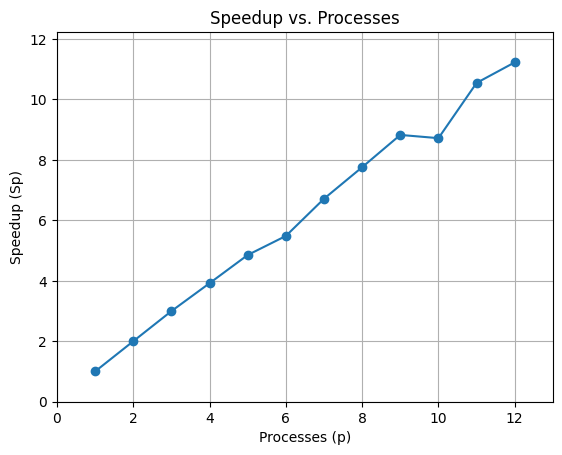

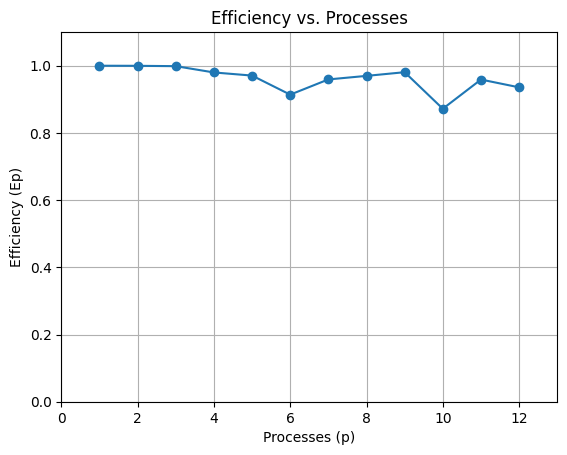

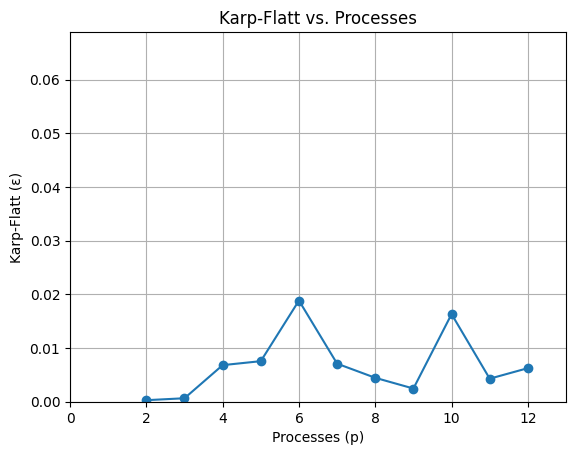

In [14]:

import numpy as np

def safe_max(series, default=1.0):
	"""Return a finite max for a pandas Series/array. Fallback to default if all NaN/Inf."""
	arr = np.asarray(series, dtype=float)
	if arr.size == 0 or np.all(np.isnan(arr)):
		return float(default)
	m = np.nanmax(arr)
	if not np.isfinite(m):
		return float(default)
	return float(m)

# compute safe maxima
xmax = safe_max(avg_df['Threads'], default=1.0)
speedup_max = safe_max(avg_df['Speedup'], default=1.0)
eff_max = safe_max(avg_df['Efficiency'], default=1.0)
kf_max = safe_max(avg_df['Karp_Flatt'], default=0.0)

# Speedup plot
plt.figure()
plt.plot(avg_df['Threads'].to_numpy(), avg_df['Speedup'].to_numpy(), marker='o')
plt.xlabel('Processes (p)')
plt.ylabel('Speedup (Sp)')
plt.title('Speedup vs. Processes')
plt.grid(True)
plt.xlim(0, xmax + 1)
plt.ylim(0, speedup_max + 1)
plt.savefig(f'{output_dir}speedup.png')

# Efficiency plot
plt.figure()
plt.plot(avg_df['Threads'].to_numpy(), avg_df['Efficiency'].to_numpy(), marker='o')
plt.xlabel('Processes (p)')
plt.ylabel('Efficiency (Ep)')
plt.title('Efficiency vs. Processes')
plt.grid(True)
plt.xlim(0, xmax + 1)
# Ensure a small positive margin even if eff_max is zero
plt.ylim(0, eff_max + max(0.1, eff_max * 0.05))
plt.savefig(f'{output_dir}efficiency.png')

# Karp-Flatt plot
plt.figure()
plt.plot(avg_df['Threads'].to_numpy(), avg_df['Karp_Flatt'].to_numpy(), marker='o')
plt.xlabel('Processes (p)')
plt.ylabel('Karp-Flatt (ε)')
plt.title('Karp-Flatt vs. Processes')
plt.grid(True)
plt.xlim(0, xmax + 1)
# Use a reasonable margin when values are very small
plt.ylim(0, kf_max + max(0.05, kf_max * 0.1))
plt.savefig(f'{output_dir}karp_flatt.png')

print(f"Plots saved in '{output_dir}' directory.")
